In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import joblib

In [84]:
df = pd.read_csv("../csv/clean_cars.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   brand          4009 non-null   object 
 1   model          4009 non-null   object 
 2   model_year     4009 non-null   int64  
 3   milage         4009 non-null   int64  
 4   fuel_type      4009 non-null   object 
 5   transmission   4009 non-null   object 
 6   ext_col        4009 non-null   object 
 7   int_col        4009 non-null   object 
 8   accident       4009 non-null   int64  
 9   clean_title    4009 non-null   int64  
 10  price          4009 non-null   int64  
 11  fuel_type_num  4009 non-null   int64  
 12  engine_liters  4009 non-null   float64
 13  cylinders      4009 non-null   int64  
 14  turbo          4009 non-null   int64  
 15  horsepower     4009 non-null   int64  
 16  brand_num      4009 non-null   int64  
 17  fuel_diesel    4009 non-null   int64  
 18  fuel_ele


#### Preparamos x e y

In [85]:
# Target
y = df['price']

# Features (SOLO numéricas)
x = df.drop(columns=[
    'price',
    'brand',
    'transmission',
    'int_col',
    'ext_col',
    'model',
    'fuel_type',
    'fuel_type_num',
    'brand_num'
])

y_log = np.log1p(y)

x_train, x_test, y_train, y_test = train_test_split(
    x, y_log, test_size=0.2, random_state=42
)

y_test_real = np.expm1(y_test)


#### Métricas de evaluación

In [86]:
def evaluate_model(y_true, y_pred):
    return{
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

#### Baseline: Regresión Lineal

In [87]:
lr = LinearRegression()
lr.fit(x_train, y_train)

y_pred_lr = np.expm1(lr.predict(x_test))


#### Ridge / Lasso

In [88]:
ridge = Ridge(alpha=1.0)
ridge.fit(x_train, y_train)

y_pred_ridge = np.expm1(ridge.predict(x_test))

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

lasso = Lasso(alpha=0.001, max_iter=10000)
lasso.fit(x_train_scaled, y_train)

y_pred_lasso = np.expm1(lasso.predict(x_test_scaled))


#### Random Forest Regressor

In [89]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=1
)

rf.fit(x_train, y_train)
y_pred_rf = np.expm1(rf.predict(x_test))

#### Gradient Boosting

In [90]:
gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr.fit(x_train, y_train)
y_pred_gbr = np.expm1(gbr.predict(x_test))

#### Comparar modelos

In [91]:
results = {
    'Linear': evaluate_model(y_test_real, y_pred_lr),
    'Ridge': evaluate_model(y_test_real, y_pred_ridge),
    'Lasso': evaluate_model(y_test_real, y_pred_lasso),
    'RF': evaluate_model(y_test_real, y_pred_rf),
    'GBR': evaluate_model(y_test_real, y_pred_gbr)
}

pd.DataFrame(results).T

,MAE,RMSE,R2
Linear,23178.685769,139907.990997,0.042336
Ridge,23174.320036,139913.000591,0.042267
Lasso,23167.446662,139917.620541,0.042204
RF,18319.567147,132874.948561,0.136198
GBR,19101.893384,135045.835602,0.107742


#### Elección del modelo


##### RMSE
##### Random Forest / GBR

In [92]:
importances = pd.Series(
    gbr.feature_importances_,
    index = x.columns
).sort_values(ascending=False)

importances.head(15)

milage           0.460304
model_year       0.246901
horsepower       0.164381
engine_liters    0.093693
cylinders        0.019832
turbo            0.005660
fuel_diesel      0.005533
fuel_gasoline    0.002167
accident         0.001221
clean_title      0.000247
fuel_hybrid      0.000060
fuel_electric    0.000000
dtype: float64

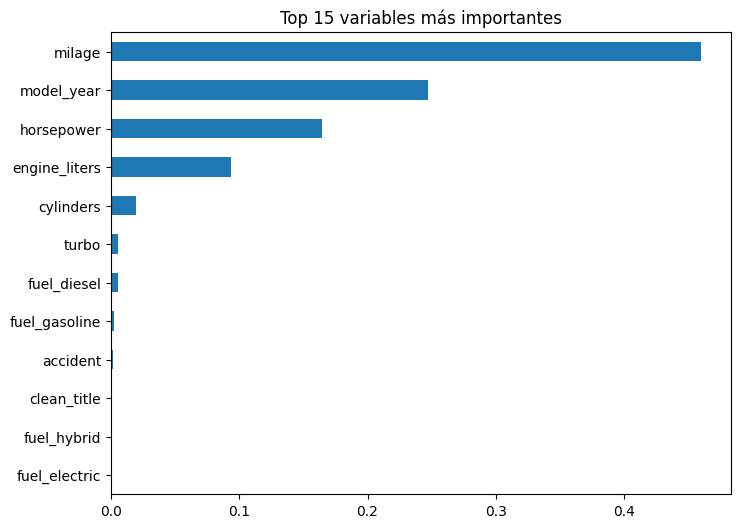

In [93]:
importances.head(15).plot(kind='barh', figsize=(8,6))
plt.title('Top 15 variables más importantes')
plt.gca().invert_yaxis()
plt.show()

##### Lasso

In [94]:
lasso_coef = pd.Series(
    lasso.coef_,
    index=x.columns
).sort_values()

lasso_coef[lasso_coef != 0].tail(10)

clean_title     -0.078998
fuel_gasoline   -0.048415
accident        -0.040735
fuel_diesel      0.028792
cylinders        0.062098
turbo            0.115390
fuel_electric    0.140417
horsepower       0.156381
engine_liters    0.222797
model_year       0.266504
dtype: float64

#### Análisis de errores

##### Predicción vs real

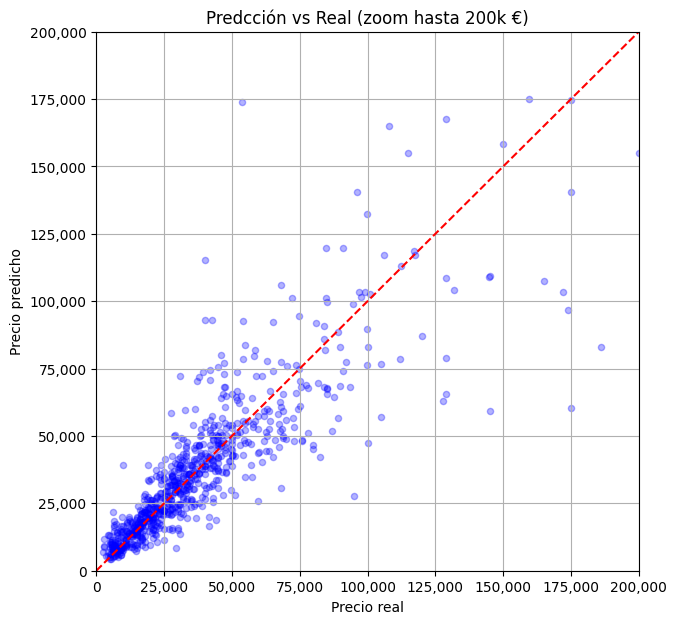

In [95]:
plt.figure(figsize=(7,7))
plt.scatter(y_test_real, y_pred_gbr, alpha=0.3, s=20, color='blue', label='Predcciones')

plt.plot([0, 200_000], [0, 200_000], linestyle='--', color='red', label='Perfecto ajuste')

# Limitar ejes para ver la mayoría de coches
plt.xlim(0, 200_000)
plt.ylim(0, 200_000)

plt.xlabel('Precio real')
plt.ylabel('Precio predicho')
plt.title('Predcción vs Real (zoom hasta 200k €)')

plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.grid(True)
plt.show()

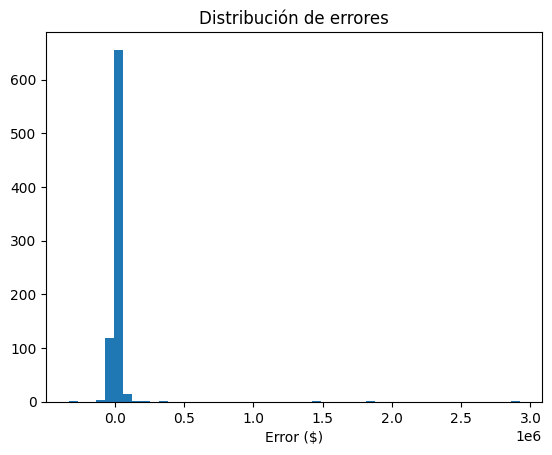

In [96]:
errors = y_test_real - y_pred_gbr

plt.hist(errors, bins=50)
plt.title('Distribución de errores')
plt.xlabel('Error ($)')
plt.show()

#### Validación cruzada

In [97]:
cv_rmse = np.sqrt(
    -cross_val_score(
        gbr, x, y_log,
        cv=5,
        scoring='neg_mean_squared_error'
    )
)

cv_rmse.mean(), cv_rmse.std()

(np.float64(0.36536736565954014), np.float64(0.026867503823501275))

#### Ajuste de hiperparametros

In [98]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.03, 0.05]
}

grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid.fit(x_train, y_train)
grid.best_params_

{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}

#### Preparar modelo

In [99]:
# Crear el encoder
le = LabelEncoder()

# Convertir la columna brand a números
df["brand_num"] = le.fit_transform(df["brand"])

# Ver resultado
df[["brand", "brand_num"]].head()

,brand,brand_num
0,Ford,14
1,Hyundai,19
2,Lexus,27
3,INFINITI,20
4,Audi,3


In [100]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
brand_encoded = ohe.fit_transform(df[['brand']])

# Guardar el encoder para la app
joblib.dump(ohe, "../models/ohe_brand.pkl")

['../models/ohe_brand.pkl']

In [101]:
joblib.dump(ridge, '../models/ridge_model.pkl')
joblib.dump(rf, '../models/rf_model.pkl')
joblib.dump(gbr, '../models/gbr_model.pkl')
joblib.dump(le, "../models/label_encoder_brand.pkl")
joblib.dump(y_test, "../models/y_test_real.pkl")
joblib.dump(y_pred_gbr, "../models/y_pred_gbr.pkl")
joblib.dump(y_pred_rf, "../models/y_pred_rf.pkl")
joblib.dump(y_pred_ridge, "../models/y_pred_ridge.pkl")


['../models/y_pred_ridge.pkl']